# Step 6.0 — Sanity Check do Modelo Final (LR, 6 meses)

## 🎯 Objetivo
Antes de avançar para o capítulo de explicabilidade (XAI), validar o **ponto de operação** do modelo final:
- o modelo (Logistic Regression) produz probabilidades `P(rapid)`
- a decisão binária (rapid/slow) depende do **threshold**

Este notebook verifica se o threshold inicialmente proposto é **operacionalmente razoável**, e documenta o trade-off entre:
- **FN (rapids falhados)** — erro mais crítico se quisermos alta sensibilidade
- **FP (falsos alarmes)** — custo operacional (alertas em excesso)

## 📥 Inputs
- `01_data/processed/dataset_6m_v1.csv`
- `models/final_lr_6m.joblib`
- `models/final_lr_6m_metadata.json`

## 📤 Outputs (para prova/traço metodológico)
- `04_outputs/tables/step6_sanity_threshold_checks.csv`
- `04_outputs/tables/step6_sanity_threshold_curve.csv`
- (opcional) `04_outputs/figures/step6_sanity_f2_vs_threshold.png`

<div style="padding:10px;border-left:6px solid #FF5F5D;">
<b>Nota:</b> este sanity check não serve para “melhorar performance” nem para estimar generalização.
Serve para validar que o threshold escolhido produz um regime de decisão coerente antes de gerar explicações XAI.
</div>


## 1) Carregar modelo final e dados (6m)

Carregamos:
- o dataset final de 6 meses (features @t0 + slope_180d)
- o pipeline treinado (preprocessamento + Logistic Regression)
- o metadata (inclui `slope_cutoff_30pct` e o threshold inicial)

Depois:
- reconstruímos o `y_true` (rapid/slow) a partir do cut-off do slope
- calculamos probabilidades `P(rapid)` para todos os doentes


In [1]:
import os
import json
import numpy as np
import pandas as pd
import joblib

from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, fbeta_score

DATASET_6M = os.path.join("..", "01_data", "processed", "dataset_6m_v1.csv")
MODEL_PATH = os.path.join("..", "models", "final_lr_6m.joblib")
META_PATH  = os.path.join("..", "models", "final_lr_6m_metadata.json")

df = pd.read_csv(DATASET_6M)
pipe = joblib.load(MODEL_PATH)

with open(META_PATH, "r", encoding="utf-8") as f:
    meta = json.load(f)

slope_col = meta["slope_col"]
slope_cutoff = meta["slope_cutoff_30pct"]
thr_final = meta["decision_threshold"]
feat_cols = meta["feature_cols"]

# target "rapid" (mesma regra do treino final)
y_true = (df[slope_col] <= slope_cutoff).astype(int).to_numpy()

X = df[feat_cols].copy()
proba = pipe.predict_proba(X)[:, 1]

print("N:", len(df), "| rapid% true:", y_true.mean(), "| slope_cutoff:", slope_cutoff, "| thr_final:", thr_final)
print("proba min/mean/max:", proba.min(), proba.mean(), proba.max())

N: 1392 | rapid% true: 0.30028735632183906 | slope_cutoff: -1.2475211387112373 | thr_final: 0.3
proba min/mean/max: 0.002702533551993118 0.4832940097725675 0.9227462396405376


## 2) Avaliar diferentes thresholds (ponto de operação)

Um modelo probabilístico precisa de um threshold para converter probabilidade em decisão.
Aqui comparamos 3 thresholds:

1) **threshold do metadata** (inicial)  
2) **0.50** (ponto “neutro” típico)  
3) **threshold que produz ~30% positivos previstos**  
   (útil como referência, porque a prevalência de rapid é ~30%)

### Métricas que usamos
- **pred_pos_rate**: percentagem prevista como rapid (carga operacional)
- **precision**: entre os previstos rapid, quantos são rapid (qualidade do alerta)
- **recall**: entre os rapid reais, quantos foram detetados (sensibilidade)
- **F2**: dá mais peso ao recall (alinhado com “não falhar rapids”)
- **TN/FP/FN/TP**: matriz de confusão (impacto operacional direto)

<b>Interpretação clínica:</b> threshold baixo tende a reduzir FN, mas aumenta FP; threshold alto faz o inverso.

In [7]:
def eval_at_threshold(y_true, proba, thr, beta=2):
    y_pred = (proba >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()

    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    f2   = fbeta_score(y_true, y_pred, beta=beta, zero_division=0)

    return {
        "thr": float(thr),
        "pred_pos_rate": float(y_pred.mean()),
        "TN": int(tn), "FP": int(fp), "FN": int(fn), "TP": int(tp),
        "precision": float(prec),
        "recall": float(rec),
        "F1": float(f1),
        "F2": float(f2),
    }

# threshold que produz ~30% positivos previstos (para comparação)
thr_30pct_pred = float(np.quantile(proba, 1 - 0.30))

checks = [
    eval_at_threshold(y_true, proba, thr_final),
    eval_at_threshold(y_true, proba, 0.50),
    eval_at_threshold(y_true, proba, thr_30pct_pred),
]

pd.DataFrame(checks)

,thr,pred_pos_rate,TN,FP,FN,TP,precision,recall,F1,F2
0,0.300000,0.904454,116,858,17,401,0.318507,0.959330,0.478235,0.684067
1,0.500000,0.436063,623,351,162,256,0.421746,0.612440,0.499512,0.561650
2,0.553831,0.300287,744,230,230,188,0.449761,0.449761,0.449761,0.449761


## 3) Curva threshold → (precision, recall, F2, taxa de positivos)

Em vez de escolher threshold “às cegas”, varremos um conjunto de thresholds (ex.: 0.05–0.95).
Isto permite:

- observar como **pred_pos_rate** desce quando o threshold sobe
- quantificar a perda de **recall** ao reduzir alertas
- encontrar um threshold final que seja um compromisso operacional

<b>Resultado esperado:</b> selecionar um threshold final que preserve recall elevado
sem transformar o modelo num “alarme que marca quase todos como rapid”.

In [3]:
ths = np.linspace(0.05, 0.95, 19)
rows = [eval_at_threshold(y_true, proba, t) for t in ths]
curve = pd.DataFrame(rows)[["thr","pred_pos_rate","precision","recall","F2"]]
curve

,thr,pred_pos_rate,precision,recall,F2
0,0.05,0.996408,0.301370,1.000000,0.683230
1,0.10,0.994971,0.301805,1.000000,0.683677
2,0.15,0.988506,0.303052,0.997608,0.684055
3,0.20,0.982040,0.305048,0.997608,0.686081
4,0.25,0.954023,0.310994,0.988038,0.688333
5,0.30,0.904454,0.318507,0.959330,0.684067
6,0.35,0.836207,0.333333,0.928230,0.684062
7,0.40,0.714080,0.358149,0.851675,0.667667
8,0.45,0.576149,0.384040,0.736842,0.622474
9,0.50,0.436063,0.421746,0.612440,0.561650


## 4) Guardar resultados do sanity check (prova da decisão)

Guardamos:
- tabela de comparação (checks) com os 3 thresholds principais
- tabela da curva completa (curve)
- (opcional) figura F2 vs threshold

Isto serve como evidência reprodutível de que o threshold final foi escolhido
com base num trade-off explicitamente documentado.

In [4]:
import os

OUT_TABLES = os.path.join("..", "04_outputs", "tables")
os.makedirs(OUT_TABLES, exist_ok=True)

checks_path = os.path.join(OUT_TABLES, "step6_sanity_threshold_checks.csv")
curve_path  = os.path.join(OUT_TABLES, "step6_sanity_threshold_curve.csv")

pd.DataFrame(checks).to_csv(checks_path, index=False)
curve.to_csv(curve_path, index=False)

print("Guardado:", checks_path)
print("Guardado:", curve_path)

Guardado: ..\04_outputs\tables\step6_sanity_threshold_checks.csv
Guardado: ..\04_outputs\tables\step6_sanity_threshold_curve.csv


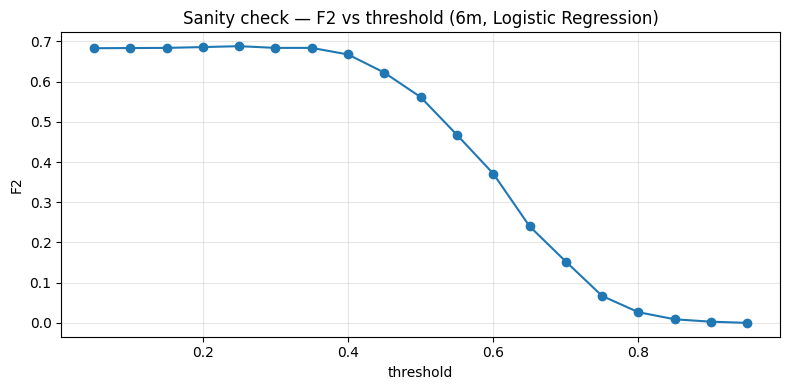

Guardado: ..\04_outputs\figures\step6_sanity_f2_vs_threshold.png


In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.plot(curve["thr"], curve["F2"], marker="o")
plt.xlabel("threshold")
plt.ylabel("F2")
plt.title("Sanity check — F2 vs threshold (6m, Logistic Regression)")
plt.grid(True, alpha=0.3)
plt.tight_layout()

fig_path = os.path.join("..", "04_outputs", "figures", "step6_sanity_f2_vs_threshold.png")
os.makedirs(os.path.dirname(fig_path), exist_ok=True)
plt.savefig(fig_path, dpi=300)
plt.show()
print("Guardado:", fig_path)

## 5) Atualizar o threshold final (sem re-treinar o modelo)

O threshold não altera os pesos do Logistic Regression — apenas define a regra:
> `rapid = 1` se `P(rapid) ≥ threshold`

Por isso:
- **não é necessário re-treino**
- atualizamos apenas o `final_lr_6m_metadata.json`
- o pipeline `.joblib` mantém-se igual

<b>Justificação:</b> separar “modelo” (probabilidade) de “ponto de operação” (threshold)
permite ajustar a decisão ao custo clínico (FN vs FP) sem alterar o estimador.

In [6]:
import json
import os

META_PATH = os.path.join("..", "models", "final_lr_6m_metadata.json")

with open(META_PATH, "r", encoding="utf-8") as f:
    meta = json.load(f)

meta["decision_threshold_old"] = meta.get("decision_threshold", None)
meta["decision_threshold"] = 0.40
meta["decision_threshold_reason"] = "sanity-check trade-off: keep recall high while reducing predicted positives"

with open(META_PATH, "w", encoding="utf-8") as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

print("Atualizado:", META_PATH)
print("old -> new:", meta["decision_threshold_old"], "->", meta["decision_threshold"])

Atualizado: ..\models\final_lr_6m_metadata.json
old -> new: 0.3 -> 0.4


## ✅ Takeaways (para ligar ao Step 6 — XAI)

- O sanity check confirmou que o threshold inicial era demasiado agressivo
  (taxa de positivos prevista demasiado elevada).
- Foi selecionado um threshold final mais operacional,
  preservando recall elevado e reduzindo alertas em excesso.
- Com o threshold final fixo, avançamos para XAI:
  - explicação global (quais features influenciam o risco)
  - explicação local (TP/FP/FN/TN) com decisões consistentes.